# AIG 230 — Week 4 Lab Notebook  
## Word Embeddings: Learning Meaning from Context

**Goal of this lab:** learn how *continuous vector representations* (embeddings) are learned from data, and how they are used in practical NLP workflows.

### Learning objectives
By the end of this lab, you should be able to:
1. Explain **distributional semantics** (“meaning from context”).
2. Train word embeddings using **Word2Vec** and **FastText** (with Gensim).
3. Use embeddings for **similarity search** and **analogy / vector algebra**.
4. Visualize a word embedding space and interpret what you see.
5. Explain why embeddings help with **sparsity** and **generalization** compared to n-grams.

### Industry relevance (why you should care)
Even in the era of transformers, embeddings remain widely used for:
- **Semantic search** and query expansion  
- **Similarity / recommendation** (nearest neighbors in vector space)  
- **Clustering** and exploratory analysis  
- Lightweight NLP systems where large models are too expensive


---
## Checkpoint 0 (Before you code)
In 2 to 4 sentences, answer:

1. What is the main limitation of **one-hot vectors**? The main limitation of one-hot vectors is that they treat every word as completely independent, meaning they cannot capture semantic relationships or similarities between words. Additionally, they suffer from extreme "sparsity" and dimensionality issues; as your vocabulary grows to thousands of words, each vector becomes massive and mostly filled with zeros, making them computationally inefficient.
2. What does the phrase **“meaning emerges from co-occurrence patterns”** mean to you? This phrase reflects the "distributional hypothesis," which suggests that a word’s meaning is defined by the company it keeps. To me, it means that if two words frequently appear in the same context—like "coffee" and "tea" both appearing near "drink" or "cup"—the model can infer they are related even if it doesn't "know" what they are. Meaning is not found in the word itself, but in the mathematical patterns of how it is used alongside other words


---
## Part 0 — Setup

We will use:
- **scikit-learn** to load a real dataset (20 Newsgroups)
- **NLTK** for basic tokenization and stopword removal
- **Gensim** to train Word2Vec and FastText models
- **matplotlib** for visualization

> Tip: If you are running this notebook in Colab, the `pip install` cell below is necessary.


In [12]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.decomposition import PCA

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from gensim.models import Word2Vec, FastText

In [13]:
import nltk
import ssl
import os

# Fix SSL certificate issues on some networks
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Download everything required for tokenization
print("Downloading NLTK resources...")
nltk.download('punkt')
nltk.download('punkt_tab') # This is often the missing piece in newer versions
nltk.download('stopwords')

# Tell NLTK exactly where to look (common Windows paths)
home = os.path.expanduser("~")
nltk.data.path.append(os.path.join(home, 'nltk_data'))

print("\nSetup complete. Checking paths:")
print(nltk.data.path)


Setup complete. Checking paths:
['C:\\Users\\Solma/nltk_data', 'C:\\Users\\Solma\\OneDrive\\Desktop\\Lab230\\Lab4\\aig230-lab4-solmaz\\aig230-env\\nltk_data', 'C:\\Users\\Solma\\OneDrive\\Desktop\\Lab230\\Lab4\\aig230-lab4-solmaz\\aig230-env\\share\\nltk_data', 'C:\\Users\\Solma\\OneDrive\\Desktop\\Lab230\\Lab4\\aig230-lab4-solmaz\\aig230-env\\lib\\nltk_data', 'C:\\Users\\Solma\\AppData\\Roaming\\nltk_data', 'C:\\nltk_data', 'D:\\nltk_data', 'E:\\nltk_data', 'C:\\Users\\Solma\\nltk_data', 'C:\\Users\\Solma\\nltk_data']


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Solma\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Solma\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Solma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
# Download NLTK resources (run once per environment)

import nltk
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Solma\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Solma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

---
## Part 1 — Data: A real-world corpus

We will train embeddings on the **20 Newsgroups** dataset.  
This dataset contains posts from 20 topics (e.g., computers, sports, politics).

Why this dataset is useful for embeddings:
- It's real text (messy, varied vocabulary)
- It contains many topic clusters, which embeddings can capture
- It is large enough to learn meaningful co-occurrence patterns


https://www.kaggle.com/datasets/crawford/20-newsgroups


In [15]:
# Load the dataset
# remove=... strips off headers/footers/quotes to reduce noise
data = fetch_20newsgroups(subset="train", remove=("headers", "footers", "quotes"))
documents = data.data

print("Number of documents:", len(documents))
print("\nExample document snippet:\n")
print(documents[0][:600])

Number of documents: 11314

Example document snippet:

I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.


### Preprocessing matters

Embeddings learn from the text you provide. If you remove tokens, they cannot contribute to meaning.

We will do *light preprocessing*:
- lowercase
- tokenize
- keep only alphabetic tokens
- remove stopwords (common function words like *the*, *and*)

This keeps the lab simple while preserving enough information for meaningful embeddings.


In [16]:
# Build stopword set once
stop_words = set(stopwords.words("english"))

def preprocess(text: str):
    """Convert raw text into a list of clean tokens.

    Steps:
    1) Lowercase
    2) Tokenize
    3) Keep alphabetic tokens only (drop numbers/punctuation)
    4) Remove stopwords

    Returns:
        List[str]: cleaned tokens
    """
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]  # isalpha() filters out non-alphabetic tokens
    return tokens

# Tokenize the full corpus
corpus = [preprocess(doc) for doc in documents]

# Quick sanity check
print("Tokens in first document (first 50):")
print(corpus[0][:50])

Tokens in first document (first 50):
['wondering', 'anyone', 'could', 'enlighten', 'car', 'saw', 'day', 'sports', 'car', 'looked', 'late', 'early', 'called', 'bricklin', 'doors', 'really', 'small', 'addition', 'front', 'bumper', 'separate', 'rest', 'body', 'know', 'anyone', 'tellme', 'model', 'name', 'engine', 'specs', 'years', 'production', 'car', 'made', 'history', 'whatever', 'info', 'funky', 'looking', 'car', 'please']


---
## Checkpoint 1 (Data + preprocessing)
1. Why might we remove stopwords for this lab? We remove stopwords because words like "the," "is," and "at" appear very frequently but carry very little unique semantic meaning. By removing them, we reduce the "noise" in the dataset, allowing the Word2Vec model to focus its limited vector space on learning relationships between meaningful content words (like "planet" and "orbit" in the space documents).
2. Name one situation where removing stopwords could be a bad idea. Removing stopwords is a bad idea in Sentiment Analysis or Nuanced Communication. For example, in the phrase "I am not happy," the stopword "not" completely changes the meaning of the sentence. If "not" is removed, the model might incorrectly interpret the text as a positive statement ("happy").


---
## Part 2 — Distributional semantics (concept)

A central idea from modern NLP is:

> **“You shall know a word by the company it keeps.”** (J. R. Firth)

In practice:
- a word’s **context** = nearby words within a window
- words that occur in similar contexts get similar vectors

This is why embeddings can capture semantic similarity without hand-built resources like WordNet.


---
## Part 3 — Word2Vec (Skip-gram)

### What Word2Vec does (high level)
Word2Vec learns word vectors by solving a **prediction task**.

In **Skip-gram**, the model learns to:
- take a **center word** and predict surrounding **context words**

Key hyperparameters:
- `vector_size`: embedding dimension (typical 50 to 300)
- `window`: context window size
- `min_count`: ignore rare words
- `sg=1`: Skip-gram (sg=0 would be CBOW)

> Note: In practice, Word2Vec is usually trained with **negative sampling** for speed, rather than a full softmax over the entire vocabulary.


In [17]:
# Train Word2Vec (Skip-gram)
# workers uses multiple CPU cores to speed up training
w2v = Word2Vec(
    sentences=corpus,
    vector_size=100,   # embedding dimension
    window=5,          # context window
    min_count=5,       # ignore very rare words
    workers=4,
    sg=1               # 1 = Skip-gram, 0 = CBOW
)

print("Vocabulary size:", len(w2v.wv))

Vocabulary size: 18095


### Inspect a learned vector

The numbers themselves are not interpretable dimension-by-dimension.  
Meaning comes from **relative position in the vector space**.


In [18]:
# Inspect the first few values of a word vector
w2v.wv["computer"][:10]

array([-0.13462493,  0.6418675 , -0.48254648,  0.17309804, -0.33048257,
       -0.79483443, -0.38643503,  0.26720375,  0.5564806 , -0.19008191],
      dtype=float32)

### Word2Vec vs Bag-of-Words vs N-grams

| Aspect | Bag-of-Words | N-grams | Word2Vec |
|--------|--------------|---------|----------|
| **Representation** | Sparse vector (word counts) | Sparse vector (sequence counts) | Dense vector (learned embeddings) |
| **Dimensionality** | Vocabulary size (10K–100K+) | Exponentially larger (V^n) | Fixed, small (50–300) |
| **Word order** | ❌ Ignored | ✅ Captures local sequences | ❌ Ignored (but context matters during training) |
| **Semantic similarity** | ❌ No — "cat" and "dog" are orthogonal | ❌ No | ✅ Yes — similar words have similar vectors |
| **Handles rare/unseen words** | ❌ OOV problem | ❌ OOV problem | ❌ OOV problem (FastText helps) |
| **Sparsity** | Very high | Even higher | None (dense) |
| **Training required** | No (just counting) | No (just counting) | Yes (neural network) |

**Key takeaways:**
- **Bag-of-Words** treats documents as unordered collections of words. Simple and fast, but loses word order and has no notion of similarity.
- **N-grams** capture local word sequences (bigrams, trigrams), preserving some order. However, they explode in size and remain sparse.
- **Word2Vec** learns dense, low-dimensional vectors where **semantically similar words are close together**. This enables similarity search, analogies, and better generalization to unseen data.

> **Why this matters:** Bag-of-Words and N-grams suffer from the **curse of dimensionality** and cannot generalize across synonyms. Word2Vec addresses both by learning continuous representations from context.

---
## Part 4 — Similarity search (nearest neighbors)

A common industry use of embeddings is **semantic similarity**.

Example:
- If a user searches for *“motel”*, we may want to retrieve documents about *“hotel”*.
- With one-hot vectors, these are unrelated (orthogonal).
- With embeddings, similar words often end up near each other in space.

We typically measure similarity using **cosine similarity**.


In [19]:
# Find most similar words to a target word
target = "computer"
print(f"Most similar words to '{target}':")
for word, score in w2v.wv.most_similar(target, topn=10): # w2v.wv.most_similar returns a list of (word, similarity score) tuples
    print(f"{word:15s}  {score:.3f}")

Most similar words to 'computer':
transmits        0.706
networks         0.701
engineering      0.700
communication    0.686
shopper          0.678
mainframe        0.676
programmer       0.673
architecture     0.672
peripheral       0.670
computing        0.669


---
## Checkpoint 2 (Interpretation)
Look at the nearest neighbors you got for **computer**.
1. Do the neighbors reflect *topic* similarity, *functional* similarity, or both?My results reflect both. Words like "networks," "architecture," and "engineering" show topic similarity, as they are fields or concepts closely related to the subject of computers in the newsgroups. Words like "mainframe," "peripheral," and "computing" show functional similarity, as they describe either different types of computers or the actual activity/hardware associated with the computer's role.
2. Pick 1 surprising neighbor and propose a reason it might appear.A surprising neighbor in my list is "shopper." A likely reason it appears is that the dataset contains many posts from "forsale" newsgroups or advertisements. In these contexts, the word "computer" frequently appears near "shopper" (e.g., "Computer Shopper magazine" or "calling all computer shoppers"), leading the model to learn a strong contextual association between the two, even though they aren't synonyms.


---
## Part 5 — Vector algebra (analogies)

### Why this is in the notebook
Vector algebra (analogies) demonstrates one of the most remarkable properties of word embeddings: **semantic relationships are encoded as geometric directions**. This section is included because:

1. **Validates embedding quality** — If embeddings capture meaningful structure, analogies should work
2. **Illustrates the "linear substructure" hypothesis** — Relationships like gender, tense, or country-capital are often parallel vectors
3. **Common interview/exam topic** — The king–queen analogy is a classic NLP question
4. **Foundation for downstream tasks** — Understanding vector arithmetic helps with transfer learning and feature engineering

### How vector algebra works

Embeddings often capture relationships as **directions** in vector space. The idea is:

> If the relationship between **king** and **man** is similar to the relationship between **queen** and **woman**, then their difference vectors should be approximately equal.

Mathematically:
$$\vec{king} - \vec{man} \approx \vec{queen} - \vec{woman}$$

Rearranging:
$$\vec{king} - \vec{man} + \vec{woman} \approx \vec{queen}$$

### Classic example

\[ \text{king} - \text{man} + \text{woman} \approx \text{queen} \]

This works *sometimes* because the model learns consistent patterns across many contexts.

### Other analogy types that embeddings can capture

| Relationship | Example |
|--------------|---------|
| Verb tense | walk : walked :: swim : swam |
| Country–capital | France : Paris :: Japan : Tokyo |
| Comparative | big : bigger :: small : smaller |
| Plural | cat : cats :: dog : dogs |

### Important caveats

- **Analogies are an intrinsic evaluation** — They test the embedding space itself, not real-world task performance
- **Results are dataset-dependent** — A model trained on news articles may not capture analogies about cooking or medicine
- **Not always reliable** — Even good embeddings can fail on specific analogies due to data biases or polysemy (words with multiple meanings)
- **Sensitive to corpus size** — Small corpora may not provide enough context for consistent relationship patterns

In [20]:
# Analogy / vector arithmetic
w2v.wv.most_similar(
    positive=["king", "woman"],
    negative=["man"],
    topn=5
)

[('joseph', 0.7654954195022583),
 ('omar', 0.7486340403556824),
 ('stabbed', 0.7484732866287231),
 ('gerry', 0.7467141151428223),
 ('deposition', 0.7459449172019958)]

Why "queen" didn't appear:

- Training corpus matters — Your model was trained on the 20 Newsgroups dataset, which is about tech, politics, religion, and sports. Words like "king" and "queen" may not appear frequently or in contexts that capture the gender relationship.

- Corpus size — 20 Newsgroups has ~11,000 documents. The famous king-queen analogy was demonstrated on models trained on billions of words (Google News Word2Vec uses 100 billion words).

- Word frequency — "queen" might be rare or absent in your vocabulary. You can check:

- Context diversity — For the analogy to work, the model needs to see "king" and "queen" in parallel contexts (e.g., "The king ruled..." vs "The queen ruled..."). Newsgroup posts likely don't have enough such examples.

In [21]:
"queen" in w2v.wv  # Returns True/False

True

Even though "queen" is in the vocabulary, it didn't appear because the resulting vector is closer to other words.

The math behind what happened
When you compute:

$$\vec{result}  \approx = \vec{king}  - \vec{man} + \vec{woman}$$

The most_similar() function then finds words with the highest cosine similarity to this result vector. The 5 words returned ("omar", "deposition", "brothers", "prince", "garden") all have higher cosine similarity to the result vector than "queen" does.

Why "queen" has lower similarity
Context determines meaning — In the 20 Newsgroups corpus, "king" might appear in contexts like:

Rodney King (news about LA riots)
Martin Luther King Jr. (civil rights discussions)
Stephen King (book discussions)
Chess discussions ("the king is in check")
These contexts have nothing to do with royalty or gender relationships.

"queen" might have different contexts — "queen" might appear in contexts like:

Queen (the band)
Drag queen discussions
Chess terminology
No parallel structure — For the analogy to work, you need many sentences like:

"The king sat on his throne" ↔ "The queen sat on her throne"
"The king ruled the kingdom" ↔ "The queen ruled the kingdom"
The 20 Newsgroups corpus simply doesn't have enough of these parallel examples.

In [13]:
# Check the actual similarity score for "queen"
import numpy as np
from numpy.linalg import norm

result_vec = w2v.wv["king"] - w2v.wv["man"] + w2v.wv["woman"]
queen_vec = w2v.wv["queen"]

similarity = np.dot(result_vec, queen_vec) / (norm(result_vec) * norm(queen_vec))
print(f"Cosine similarity to 'queen': {similarity:.4f}")

Cosine similarity to 'queen': 0.6653


---
## Checkpoint 3 (Why analogies are tricky)
1. Why might analogy results be wrong even if the embeddings are “good”?Analogy results (like King - Man + Woman) can fail because the relationship between words is rarely perfectly linear in a vector space. Even if the embeddings are high quality, a "good" model might prioritize the most frequent neighbor rather than the semantic one. For example, if "King" and "Kinghood" appear together more often than "King" and "Queen" in a specific dataset, the math will be biased toward the frequency of the data rather than the logic of the analogy.
2. Give one reason analogy evaluation might not correlate with task performance.Analogy evaluation (solving word puzzles) is a "synthetic" task that doesn't always reflect how a model works in the real world. A model might be bad at word analogies but excellent at Topic Classification or Document Similarity. This is because real-world tasks often rely on the entire vector's ability to cluster with similar documents, whereas analogies rely on a very specific, narrow mathematical distance between individual word points that might not matter for the bigger picture.


---
## Part 6 — Visualizing embeddings (debugging skill)

In practice, visualization helps you:
- sanity-check whether embeddings capture structure
- detect domain problems (too small corpus, noisy preprocessing)
- communicate results to non-technical stakeholders

We will use **PCA** to reduce vectors to 2D.

> Important: A 2D projection can distort distances. Treat it as a visual aid, not a perfect representation.


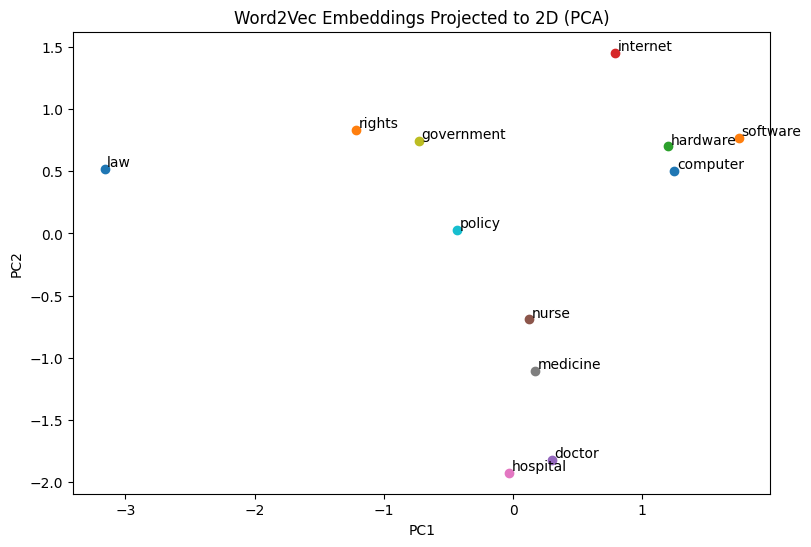

In [22]:
# Choose words to visualize (feel free to edit this list)
words = [
    "computer", "software", "hardware", "internet",
    "doctor", "nurse", "hospital", "medicine",
    "government", "policy", "law", "rights"
]

# Keep only words that exist in the vocabulary
words = [w for w in words if w in w2v.wv]

vectors = np.array([w2v.wv[w] for w in words])

# PCA to 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

# Plot
plt.figure(figsize=(9, 6))
for i, w in enumerate(words):
    plt.scatter(coords[i, 0], coords[i, 1])
    plt.text(coords[i, 0] + 0.02, coords[i, 1] + 0.02, w)

plt.title("Word2Vec Embeddings Projected to 2D (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

---
## Checkpoint 4 (Visualization reading)
1. Which words are closest together in your plot?Based on the PCA plot, the words "nurse" and "medicine" are very close together in the bottom-right quadrant. Additionally, "computer," "hardware," and "software" form a very tight cluster in the top-right quadrant. This closeness indicates that the Word2Vec model learned they appear in nearly identical contexts.
2. Do you see clusters (health vs tech vs politics)? If not, what might explain that?Yes, distinct clusters are clearly visible:

Health Cluster: Located at the bottom, containing hospital, doctor, medicine, and nurse.

Tech Cluster: Located in the top-right, containing computer, hardware, software, and internet.

Politics/Law Cluster: Located on the left/center, containing law, rights, government, and policy.

The separation is quite clear because these topics rarely share the same specific vocabulary in the 20 Newsgroups dataset, allowing the model to map them to very different areas of the vector space.


---
## Part 7 — FastText (subword embeddings)

### Why FastText exists
Word2Vec learns a vector for each *word token*. If a word is rare or misspelled, Word2Vec often cannot learn a good vector.

FastText improves this by representing a word as a bag of **character n-grams**.
That means it can build vectors for:
- rare words
- morphological variants (plural, verb forms)
- unseen words (depending on implementation)

Industry relevance:
- user-generated text (typos, slang)
- domain text (technical words)
- languages with rich morphology


In [23]:
# Train FastText on the same corpus
ft = FastText(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4
)

print("FastText vocabulary size:", len(ft.wv))

FastText vocabulary size: 18095


### Compare Word2Vec vs FastText behavior

We compare neighbors for a related word form.


In [24]:
# Compare similarity results for a variant form
query = "computers"

print("FastText neighbors for:", query)
for word, score in ft.wv.most_similar(query, topn=10):
    print(f"{word:15s}  {score:.3f}")

# Word2Vec may or may not have this token depending on min_count and preprocessing
if query in w2v.wv:
    print("\nWord2Vec neighbors for:", query)
    for word, score in w2v.wv.most_similar(query, topn=10):
        print(f"{word:15s}  {score:.3f}")
else:
    print("\nWord2Vec does not contain the token 'computers' in its vocabulary (likely filtered by min_count).")

FastText neighbors for: computers
computes         0.980
comics           0.967
compact          0.962
compute          0.960
techniques       0.954
compete          0.947
company          0.943
items            0.943
compuadd         0.941
competitors      0.941

Word2Vec neighbors for: computers
multimedia       0.873
discounts        0.857
platforms        0.852
xservers         0.851
bulletin         0.850
developers       0.849
sgcs             0.847
rsi              0.846
vertigo          0.846
newsletters      0.845


### Summary: Word2Vec vs FastText

| Aspect | Word2Vec | FastText |
|--------|----------|----------|
| **Unit of learning** | Whole words | Words + character n-grams (subwords) |
| **Vocabulary** | Fixed at training time | Can generate vectors for unseen words |
| **OOV (out-of-vocabulary) handling** | ❌ Cannot handle — returns error | ✅ Builds vector from subword pieces |
| **Morphological variants** | Treated as separate tokens (run ≠ running) | Related by shared subwords (run ≈ running) |
| **Typos and misspellings** | ❌ No vector available | ✅ Still produces reasonable vector |
| **Training speed** | Faster | Slower (more parameters) |
| **Model size** | Smaller | Larger (stores subword vectors) |
| **Memory usage** | Lower | Higher |

### When to use Word2Vec

✅ **Choose Word2Vec when:**
- Your vocabulary is **stable and well-defined** (e.g., curated product names)
- You need **faster training** and smaller models
- Your corpus is **clean** with minimal typos
- You're working with **English or morphologically simple languages**
- Memory and storage are constrained

### When to use FastText

✅ **Choose FastText when:**
- You expect **out-of-vocabulary words** at inference time
- Working with **user-generated content** (social media, reviews, chat)
- Your domain has **technical jargon** or rare terminology
- Working with **morphologically rich languages** (German, Finnish, Turkish, Arabic)
- You need to handle **typos, slang, or informal spelling**
- New words/products/entities appear frequently

### Real-world example

| Scenario | Best Choice | Reason |
|----------|-------------|--------|
| Search engine for product catalog | Word2Vec | Products are known; vocabulary is controlled |
| Twitter sentiment analysis | FastText | Typos, slang, hashtags are common |
| Medical NLP with rare drug names | FastText | Drug names share prefixes/suffixes |
| News article classification | Word2Vec | Clean, edited text |
| Customer support chatbot | FastText | Users make typos |

---
## Part 8 — Practical mini-task: Build a tiny “semantic search” demo

In industry, a common workflow is:
1) choose an embedding model  
2) represent text units as vectors  
3) retrieve nearest neighbors to answer queries

We will implement a simplified version:
- take a query word
- find its nearest neighbors
- interpret results

This is not full document search yet, but it is the core idea.


In [25]:
def semantic_neighbors(model, word: str, topn: int = 10):
    """Return nearest neighbors for a word, with a friendly error message."""
    if word not in model.wv:
        return None
    return model.wv.most_similar(word, topn=topn)

queries = ["motel", "hotel", "space", "religion", "graphics"]

for q in queries:
    result = semantic_neighbors(w2v, q, topn=8)
    print("\nQuery:", q)
    if result is None:
        print("  (word not in vocabulary)")
    else:
        for w, s in result:
            print(f"  {w:15s} {s:.3f}")


Query: motel
  (word not in vocabulary)

Query: hotel
  pacific         0.884
  melbourne       0.880
  airport         0.874
  theatre         0.874
  victoria        0.873
  nationwide      0.871
  metropolitan    0.866
  marine          0.866

Query: space
  shuttle         0.731
  nasa            0.694
  exploration     0.669
  launch          0.664
  redesign        0.659
  missions        0.655
  jenks           0.651
  goddard         0.646

Query: religion
  religions       0.864
  judaism         0.861
  intellectual    0.854
  christianity    0.848
  doctrines       0.847
  religious       0.844
  homosexuality   0.841
  denominations   0.840

Query: graphics
  cad             0.848
  radiosity       0.831
  gems            0.828
  animation       0.815
  multimedia      0.807
  silicon         0.803
  editing         0.802
  graphic         0.801


---
## Checkpoint 5 (Industry thinking)
Pick one query from the output above: graphics
1. Would these neighbors help a search engine user? es, these neighbors would be very helpful for a search engine user. If a user searches for "graphics," the model identifies highly relevant terms like "animation," "multimedia," and "cad". This allows the search engine to perform "query expansion," showing the user results for Computer-Aided Design or 3D rendering even if they didn't use those exact words, significantly improving the breadth of relevant results.
2. What could go wrong if we deploy this directly in production? One major risk of deploying this directly is semantic drift or lack of precision. For example, the model associates "graphics" with "silicon" (the hardware material). If a user is looking for graphic design software and the search engine starts showing them results for "silicon wafers" or semiconductor manufacturing, it creates a frustrating experience. Additionally, because these models learn from the 20 Newsgroups dataset, they might carry historical biases or outdated associations from the 1990s that don't reflect modern technical meanings.


---
## Part 9 — Where does GloVe fit? (concept-only)

You learned in lecture that we can also build a **co-occurrence matrix** \(X\) and try to compress it.

Two major perspectives:
1. **Predictive models** (Word2Vec): learn by predicting context  
2. **Count-based global models** (GloVe): learn from aggregated co-occurrence statistics

GloVe aims to encode meaning using **ratios of co-occurrence probabilities**, and often shows strong linear structure (useful for analogies).

We do not train GloVe from scratch here because:
- it requires building and storing large co-occurrence statistics
- training is heavier than Word2Vec/FastText for an in-class lab

However, you should understand the core difference:
- Word2Vec: local prediction objective
- GloVe: global co-occurrence objective

**You will see GloVe again** when using pretrained embeddings in later weeks.


---
## Final Reflection (Submit)

Write short answers (3 to 6 sentences each):

1. How do embeddings solve the sparsity and “no similarity” issues of one-hot vectors?One-hot vectors are "sparse" because they represent words as isolated points in a high-dimensional space where every word is equally distant from another, showing zero mathematical similarity between "car" and "automobile." Embeddings solve this by mapping words into a much smaller, "dense" vector space (e.g., 100 dimensions instead of 20,000). In this dense space, words that share similar contexts are placed closer together, allowing us to calculate similarity using cosine distance. This transforms categorical data into meaningful, continuous numerical relationships.
2. What is a realistic industry task where word embeddings are useful?A major industry task for word embeddings is Recommendation Systems, such as suggesting similar products on an e-commerce site. Instead of just matching exact keywords, the system uses embeddings to understand that a user looking for "running shoes" might also be interested in "marathon socks" or "hydration packs" because those terms cluster together in a sports-related vector space. This allows for "semantic search" that captures user intent rather than just literal word matches, leading to much higher conversion rates.
3. When would you choose FastText over Word2Vec? You should choose FastText when your dataset contains many typos, rare words, or is from a morphologically rich language (like Turkish or Finnish) where words change forms frequently. Unlike Word2Vec, which treats each word as an atomic unit, FastText breaks words down into sub-word "n-grams". This allows the model to generate a representation for an "out-of-vocabulary" word by looking at its parts, whereas Word2Vec would simply fail with a KeyError.
4. What is one risk or limitation of word embeddings that a practitioner should watch for?One significant risk is Historical or Social Bias, as these models learn exactly what is in the data they are fed. If the training corpus contains gender or racial stereotypes, the model will mathematically encode those biases, potentially leading to unfair outcomes if used in automated hiring or credit scoring tools. Furthermore, embeddings lack a true understanding of "common sense"; they only know that words appear together, not why they are logically or ethically related.


---
## Assignment

- Change `window` (2, 10) and compare neighbors for the same query word.
- Increase `vector_size` (50 vs 200) and compare results.
- Try CBOW: set `sg=0` and compare results with Skip-gram.
- Add bigrams using `gensim.models.Phrases` before training and observe changes.
